(1000, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         1000 non-null   object
 1   Price         1000 non-null   object
 2   Rating        1000 non-null   int64 
 3   Availability  1000 non-null   object
dtypes: int64(1), object(3)
memory usage: 31.4+ KB
Title           0
Price           0
Rating          0
Availability    0
dtype: int64
Duplicates: 0
Availability
In stock    1000
Name: count, dtype: int64


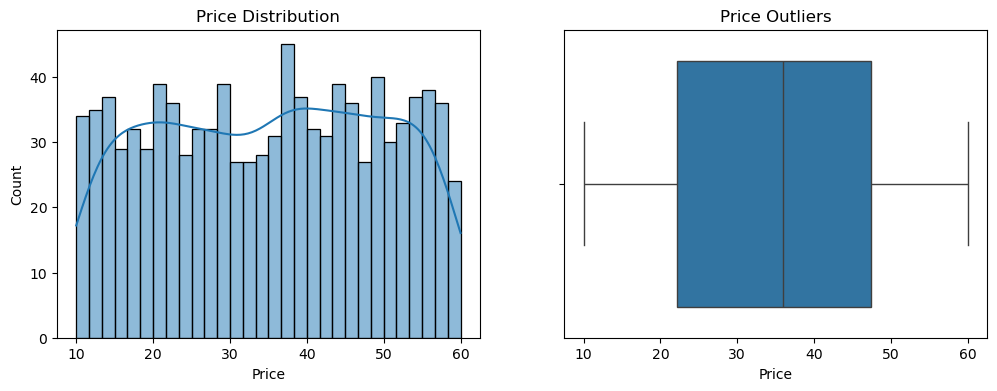

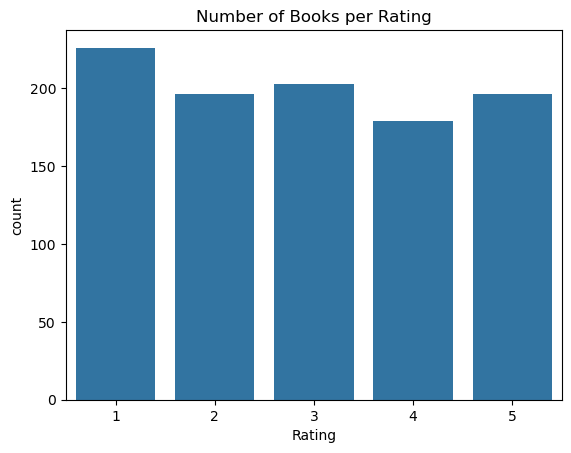

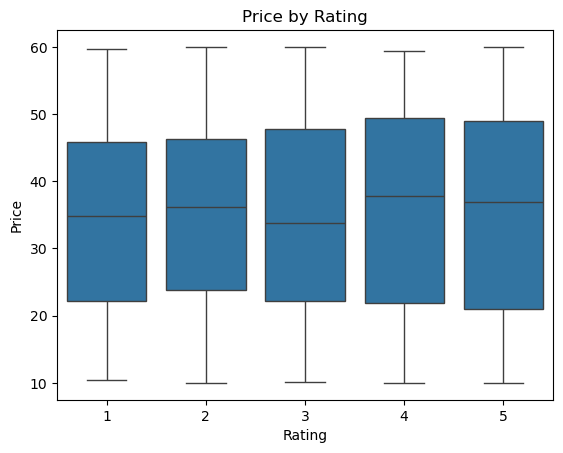

           Price    Rating
Price   1.000000  0.028166
Rating  0.028166  1.000000
Outliers: 0
t = 0.5726453857620195  p-value = 0.5672057846672589
Spearman r = 0.02921568643020118  p-value = 0.3560475336675232


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("books.csv")
print(df.shape)
df.head()

df.info()
df.describe(include="all")


print(df.isnull().sum())          # missing values
print("Duplicates:", df.duplicated().sum())
print(df["Availability"].value_counts())

df["Price"] = df["Price"].str.extract(r"(\d+\.\d+)").astype(float)
df.dtypes

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["Price"], bins=30, kde=True, ax=ax[0])
ax[0].set_title("Price Distribution")
sns.boxplot(x=df["Price"], ax=ax[1])
ax[1].set_title("Price Outliers")
plt.show()

sns.countplot(x="Rating", data=df)
plt.title("Number of Books per Rating")
plt.show()

sns.boxplot(x="Rating", y="Price", data=df)
plt.title("Price by Rating")
plt.show()
print(df[["Price", "Rating"]].corr())

q1, q3 = df["Price"].quantile([0.25, 0.75])
iqr = q3 - q1
outliers = df[(df["Price"] < q1 - 1.5*iqr) | (df["Price"] > q3 + 1.5*iqr)]
print("Outliers:", len(outliers))

#H0: There is no difference in average price between 5-star and 1-star books.
#H1: There is a difference in average price.

five = df[df["Rating"] == 5]["Price"]
one = df[df["Rating"] == 1]["Price"]

t, p = stats.ttest_ind(five, one, equal_var=False)
print("t =", t, " p-value =", p)


r, p = stats.spearmanr(df["Rating"], df["Price"])
print("Spearman r =", r, " p-value =", p)

## Key Findings
- Prices range from about £10 to £60 and are spread fairly evenly (median about £36).
- No outliers were detected in price (IQR method found 0).
- Ratings are balanced, with 1-star the most common and 4-star the least.
- Price and rating have almost no correlation (0.028).
- The t-test (p = 0.567) and Spearman test (p = 0.356) show no significant relationship
  between price and rating, so we fail to reject H0.

## Data Issues Found
- Price was stored as text with a currency symbol and had to be converted to numeric.
- Availability is "In stock" for all rows, so it carries no information.
- No missing values or duplicates were found.
- The data comes from a practice website and is artificial, so results may not reflect real markets.
- The dataset has few columns, which limits the analysis.

